In [1]:
from pathlib import Path
import sys
import numpy as np
PROJETO = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
if str(PROJETO) not in sys.path:
    sys.path.insert(0, str(PROJETO))

from mvnview.tools import print_all_shapes, print_segment_names, save_mvnx_data, print_ergonomic_joint_relations
from mvnview import *
from mvnview.MocapData import MocapData
from mvnview.primary_plots import (
    plot_abduction_byframe,
    plot_rotation_byframe,
    plot_flexion_byframe,
    plot_abduction_histogram,
    plot_rotation_histogram,
    plot_flexion_histogram,
)

In [2]:
PASTA_ARQUIVOS_MVNX = PROJETO / "capture_data" / "raw_mvnx" / "files"
PASTA_ARQUIVOS_NPZ = PROJETO / "capture_data" / "converted_npz" / "files"
PASTA_ARQUIVOS_NPZ.mkdir(parents=True, exist_ok=True)

NOME_ARQUIVO_NPZ = "captura_de_movimento_convertida.npz"
arquivo_npz_convertido = PASTA_ARQUIVOS_NPZ / NOME_ARQUIVO_NPZ
data = MocapData(arquivo_npz_convertido)

In [3]:
joints = data.get_joint_names()
print(joints)

print(joints.shape)

jangle = data.get_joint_angle('jLeftShoulder')
print(jangle)
print(jangle.shape)
import numpy as np
scalarjangle = np.linalg.norm(jangle,axis =1)
print("SPACE")
print(scalarjangle.shape)
print(scalarjangle)

['jL5S1' 'jL4L3' 'jL1T12' 'jT9T8' 'jT1C7' 'jC1Head' 'jRightT4Shoulder'
 'jRightShoulder' 'jRightElbow' 'jRightWrist' 'jLeftT4Shoulder'
 'jLeftShoulder' 'jLeftElbow' 'jLeftWrist' 'jRightHip' 'jRightKnee'
 'jRightAnkle' 'jRightBallFoot' 'jLeftHip' 'jLeftKnee' 'jLeftAnkle'
 'jLeftBallFoot']
(22,)
[[ 1.7721883e+01  1.3584609e+01  3.9883171e+01]
 [ 1.8899926e+01  1.3223037e+01  4.1551730e+01]
 [ 2.0141775e+01  1.2132601e+01  4.2636346e+01]
 [ 2.1625716e+01  9.5730860e+00  4.2720542e+01]
 [ 2.3184982e+01  6.2189370e+00  4.2078725e+01]
 [ 2.4353618e+01  3.4491630e+00  4.1262971e+01]
 [ 2.5029627e+01  1.9367980e+00  4.0642842e+01]
 [ 2.5295141e+01  1.0510540e+00  3.9989402e+01]
 [ 2.4987606e+01  2.6208700e-01  3.9076759e+01]
 [ 2.3910624e+01 -6.2100200e-01  3.7894803e+01]
 [ 2.2280354e+01 -1.3932530e+00  3.6456335e+01]
 [ 2.0571272e+01 -1.9997650e+00  3.4547166e+01]
 [ 1.8726509e+01 -2.1895900e+00  3.2120996e+01]
 [ 1.6897084e+01 -2.2405790e+00  2.9159011e+01]
 [ 1.5833288e+01 -2.8591050e+00  

In [4]:
print_all_shapes(data)
print_segment_names(data)

posição: (180, 69) --> (frames, (23 segmentos x 3 [x,y,z]))
orientação: (180, 92) --> (frames, (23 segmentos x 4 [q0,q1,q2, q3]))
tempo: (180,)
segmentos: (23,)
nomes das juntas: (22,)
ângulo das juntas: (180, 66)

velocidade: (180, 69) --> (frames, (23 segmentos x 3 [x,y,z]))
aceleração: (180, 69) --> (frames, (23 segmentos x 3 [x,y,z]))
velocidade angular: (180, 69) --> (frames, (23 segmentos x 3 [x,y,z]))
aceleração angular: (180, 69) --> (frames, (23 segmentos x 3 [x,y,z]))
contatos dos pés: (180, 4) --> (frames, (23 segmentos x 3 [x,y,z]))
aceleração livre do sensor: (180, 33) --> (frames, (23 segmentos x 3 [x,y,z]))
campo magnético do sensor: (180, 33) --> (frames, (23 segmentos x 3 [x,y,z]))
orientação do sensor: (180, 44) --> (frames, (23 segmentos x 4 [q0,q1,q2, q3]))
centro de massa: (180, 9) --> (frames, (23 segmentos x 3 [x,y,z]))
Segmentos:
Pelvis         RightUpperArm  RightLowerLeg
L5             RightForeArm   RightFoot
L3             RightHand      RightToe
T12        

In [5]:
print(data.orientation.shape)
print(data.orientation[:,0])


(180, 92)
[0.831195 0.828695 0.825781 0.821937 0.817641 0.814124 0.811932 0.810479
 0.809395 0.808012 0.806965 0.80782  0.811854 0.817387 0.821866 0.824608
 0.826677 0.828605 0.830872 0.833181 0.834901 0.835609 0.835739 0.835973
 0.83686  0.837847 0.837977 0.836458 0.833883 0.831573 0.830308 0.829466
 0.828429 0.826456 0.823942 0.822082 0.821943 0.82246  0.822036 0.819978
 0.817241 0.814892 0.813775 0.813169 0.811774 0.808294 0.803892 0.801071
 0.800803 0.802197 0.805065 0.809767 0.815735 0.821407 0.826421 0.831014
 0.834882 0.83797  0.840687 0.843557 0.846976 0.850506 0.853407 0.855717
 0.85746  0.857941 0.856154 0.852872 0.850203 0.85003  0.850408 0.84794
 0.840309 0.82947  0.81885  0.809491 0.800715 0.79384  0.790494 0.789277
 0.787019 0.781613 0.775091 0.770592 0.769232 0.769747 0.771944 0.77633
 0.782415 0.788679 0.794797 0.800932 0.806506 0.811604 0.816399 0.820635
 0.824388 0.827698 0.830223 0.831725 0.832483 0.832921 0.833434 0.833644
 0.832828 0.829939 0.825879 0.822922 0.8223

In [6]:
jointanglesXZY = data.get_jointAngleErgoXZY()
print(jointanglesXZY.shape)

jointangles = data.get_jointAngleErgo()
print(jointangles.shape)

(180, 18)
(180, 18)


In [7]:
print_ergonomic_joint_relations(
    PASTA_ARQUIVOS_MVNX / "lucas_all_tipo4.mvnx"
)

Index  Label                    Relação                          Índices das colunas na matriz
    0  T8_Head                  T8 -> Head                       0, 1, 2
    1  T8_LeftUpperArm          T8 -> LeftUpperArm               3, 4, 5
    2  T8_RightUpperArm         T8 -> RightUpperArm              6, 7, 8
    3  Pelvis_T8                Pelvis -> T8                     9, 10, 11
    4  Vertical_Pelvis          Vertical -> Pelvis               12, 13, 14
    5  Vertical_T8              Vertical -> T8                   15, 16, 17


In [8]:
xyzRightShoulderjoint = data.get_joint_angle_xzy('jRightShoulder')
print(xyzRightShoulderjoint.shape)

abduction = xyzRightShoulderjoint[:,0]   # x
rotation  = xyzRightShoulderjoint[:,1]   # y
flexion   = xyzRightShoulderjoint[:,2]   # z

print(flexion)
print(abduction)
print(rotation)

(180, 3)
[ 3.0990303e+01  3.1380399e+01  3.1948534e+01  3.2945434e+01
  3.4171806e+01  3.5207879e+01  3.5928144e+01  3.6448838e+01
  3.6705072e+01  3.6838512e+01  3.6613951e+01  3.5347044e+01
  3.2439605e+01  2.8328563e+01  2.4016765e+01  1.9752846e+01
  1.5428231e+01  1.1634598e+01  8.6005870e+00  6.1802320e+00
  4.3976940e+00  3.2729940e+00  2.7031820e+00  2.5066730e+00
  2.7022150e+00  3.3306840e+00  4.2723670e+00  5.6129790e+00
  7.2547410e+00  8.7369390e+00  9.5938780e+00  1.0292922e+01
  1.1767230e+01  1.4627546e+01  1.8251978e+01  2.1679019e+01
  2.4618326e+01  2.7312580e+01  2.9570218e+01  3.1339950e+01
  3.2636125e+01  3.3417970e+01  3.3533984e+01  3.3240752e+01
  3.3147768e+01  3.3645142e+01  3.4378284e+01  3.4808445e+01
  3.4832404e+01  3.4508797e+01  3.3497475e+01  3.1777458e+01
  2.9239332e+01  2.5503815e+01  1.9849350e+01  1.3123189e+01
  7.3810260e+00  3.5075530e+00  6.5566600e-01 -1.7480010e+00
 -3.9237240e+00 -5.6934810e+00 -7.0472750e+00 -8.0010440e+00
 -8.5177040e+00

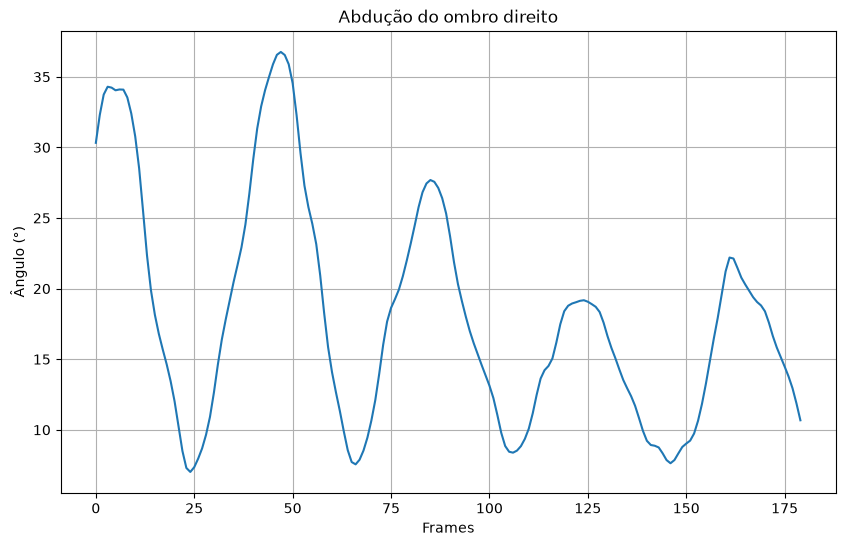

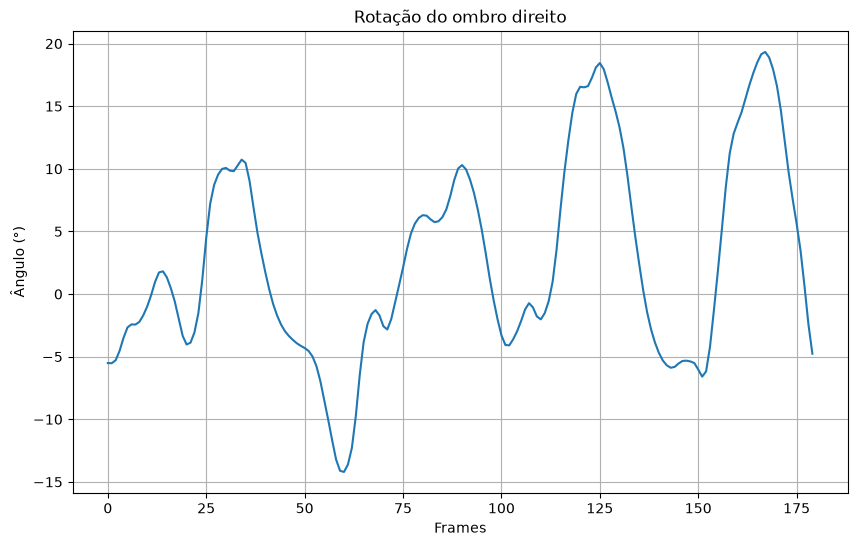

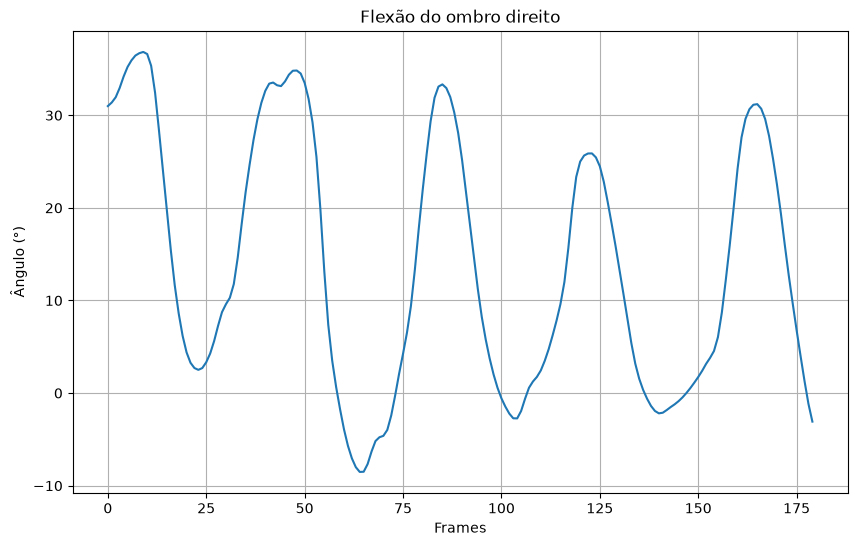

In [14]:
plot_abduction_byframe(data, 'jRightShoulder', 'Abdução do ombro direito')
plot_rotation_byframe(data, 'jRightShoulder', 'Rotação do ombro direito')
plot_flexion_byframe(data, 'jRightShoulder', 'Flexão do ombro direito')

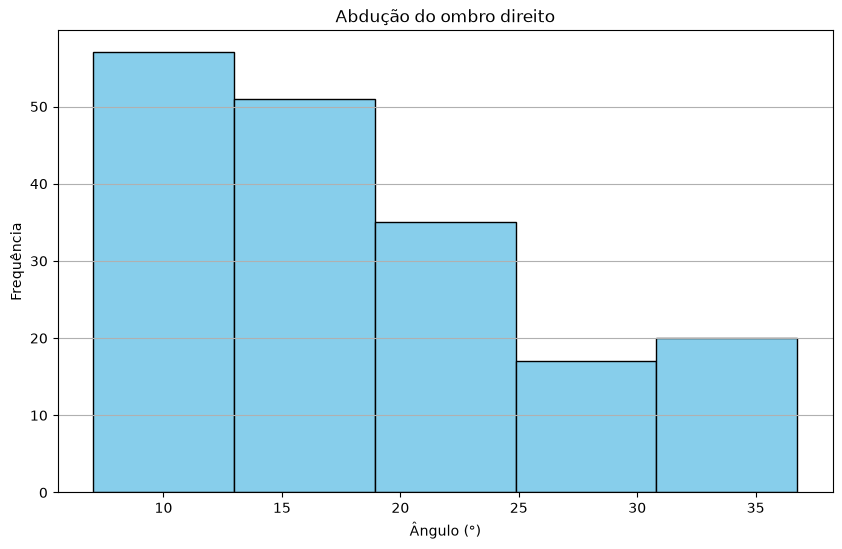

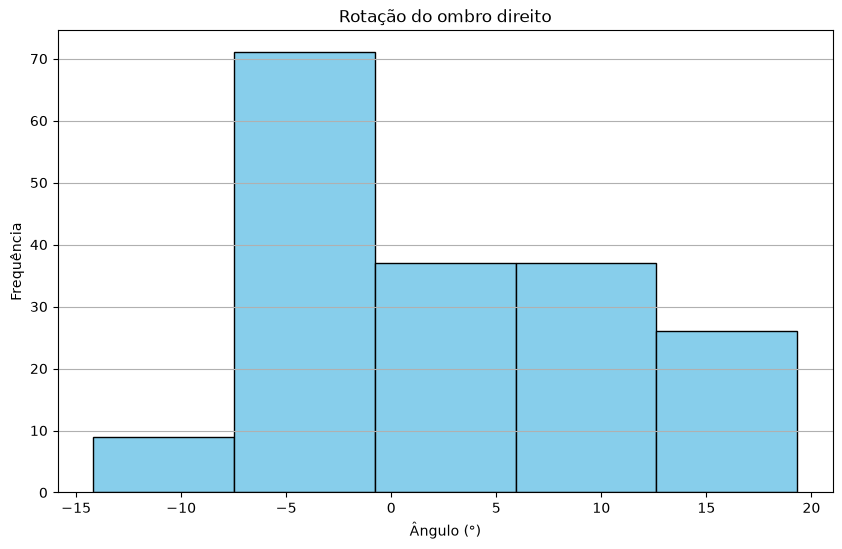

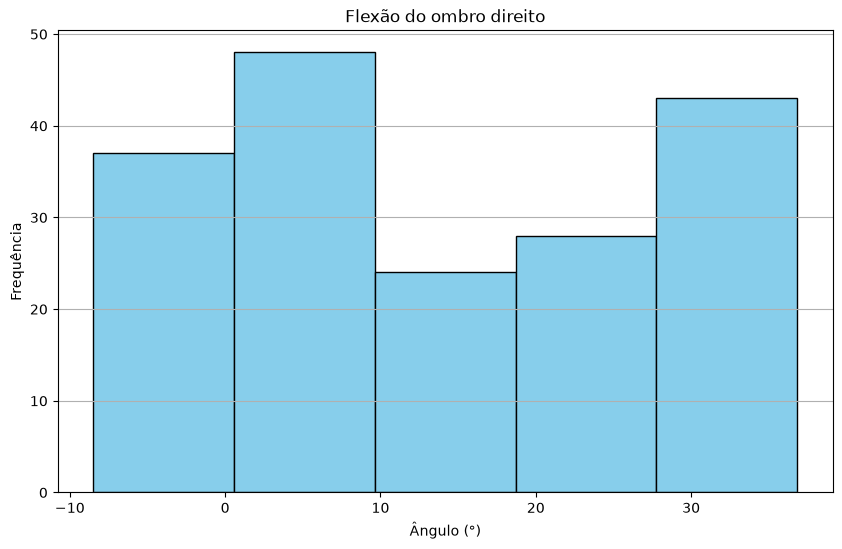

In [13]:
plot_abduction_histogram(data, 'jRightShoulder', 5 ,'Abdução do ombro direito')
plot_rotation_histogram(data, 'jRightShoulder', 5,'Rotação do ombro direito')
plot_flexion_histogram(data, 'jRightShoulder', 5,'Flexão do ombro direito')